# Quantium Virtual Internship - Retail Strategy and Analytics - Task 2

This QVI dataset captures detailed transaction-level shopping behavior, combining customer demographics, product information, store details, and sales metrics to enable rich retail analytics.

In [20]:
# Load Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [22]:
# Load dataset
data = pd.read_csv("QVI_data.csv")
data.head

<bound method NDFrame.head of         LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
0                 1000  17/10/2018          1       1         5   
1                 1002  16/09/2018          1       2        58   
2                 1003  07/03/2019          1       3        52   
3                 1003  08/03/2019          1       4       106   
4                 1004  02/11/2018          1       5        96   
...                ...         ...        ...     ...       ...   
264829         2370701  08/12/2018         88  240378        24   
264830         2370751  01/10/2018         88  240394        60   
264831         2370961  24/10/2018         88  240480        70   
264832         2370961  27/10/2018         88  240481        65   
264833         2373711  14/12/2018         88  241815        16   

                                       PROD_NAME  PROD_QTY  TOT_SALES  \
0         Natural Chip        Compny SeaSalt175g         2        6.0   
1          Red Rock

In [3]:
print(data.shape)
print(data.info)

(264834, 12)
<bound method DataFrame.info of         LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
0                 1000  17/10/2018          1       1         5   
1                 1002  16/09/2018          1       2        58   
2                 1003  07/03/2019          1       3        52   
3                 1003  08/03/2019          1       4       106   
4                 1004  02/11/2018          1       5        96   
...                ...         ...        ...     ...       ...   
264829         2370701  08/12/2018         88  240378        24   
264830         2370751  01/10/2018         88  240394        60   
264831         2370961  24/10/2018         88  240480        70   
264832         2370961  27/10/2018         88  240481        65   
264833         2373711  14/12/2018         88  241815        16   

                                       PROD_NAME  PROD_QTY  TOT_SALES  \
0         Natural Chip        Compny SeaSalt175g         2        6.0   
1   

In [31]:
# Checking for null and duplicate values
print(data.isnull().sum())
print("Duplicate values: ", data.duplicated().sum())

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
YEARMONTH           0
dtype: int64
Duplicate values:  1


In [32]:
#Removing duplicates
data.drop_duplicates(inplace=True)

#After removing duplicates
print("After removing duplicates: ", data.duplicated().sum())

After removing duplicates:  0


Creating year month column and changing the date in date-time format

In [24]:
data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811


Calculating monthly metrics for each store such as: sales, customers, transactions per customer, average price etc.

In [25]:
measureOverTime = (
    data.groupby(['STORE_NBR', 'YEARMONTH'])
        .agg(
            totSales=('TOT_SALES', 'sum'),
            nCustomers=('LYLTY_CARD_NBR', 'nunique'),
            nTransactions=('TXN_ID', 'nunique'),
            nChips=('PROD_QTY', 'sum'),
            avgPricePerUnit=('TOT_SALES', 'mean')
        )
        .reset_index()
)

measureOverTime['nTxnPerCust'] = measureOverTime['nTransactions'] / measureOverTime['nCustomers']
measureOverTime['nChipsPerTxn'] = measureOverTime['nChips'] / measureOverTime['nTransactions']

measureOverTime.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTransactions,nChips,avgPricePerUnit,nTxnPerCust,nChipsPerTxn
0,1,201807,206.9,49,52,62,3.978846,1.061224,1.192308
1,1,201808,176.1,42,43,54,4.095349,1.023810,1.255814
2,1,201809,278.8,59,62,75,4.496774,1.050847,1.209677
3,1,201810,188.1,44,45,58,4.180000,1.022727,1.288889
4,1,201811,192.6,46,47,57,4.097872,1.021739,1.212766


Filter stores present for full pre-trial period
Pre-trial: July 2018 – Jan 2019 (7 months)

In [26]:
preTrial = measureOverTime[(measureOverTime['YEARMONTH'] >= 201807) &
                           (measureOverTime['YEARMONTH'] <= 201901)]

stores_valid = preTrial.groupby('STORE_NBR').size()
stores_full = stores_valid[stores_valid == 7].index

preTrialMeasures = preTrial[preTrial['STORE_NBR'].isin(stores_full)]

### Defining Functions

In [27]:
#Function 1: Correlation between trial & each store
def calculateCorrelation(df, metric, trial_store):
    trial_series = df[df['STORE_NBR'] == trial_store][metric].values

    corr_list = []
    for store in df['STORE_NBR'].unique():
        if store != trial_store:
            compare_series = df[df['STORE_NBR'] == store][metric].values
            corr = np.corrcoef(trial_series, compare_series)[0, 1]
            corr_list.append([trial_store, store, corr])

    return pd.DataFrame(corr_list, columns=['Store1', 'Store2', 'corr_measure'])

In [28]:
# Function 2: Magnitude Distance (standardized difference)
def calculateMagnitudeDistance(df, metric, trial_store):

    rows = []
    months = df['YEARMONTH'].unique()

    for store in df['STORE_NBR'].unique():
        if store != trial_store:
            for month in months:
                trial_val = df[(df['STORE_NBR'] == trial_store) & 
                               (df['YEARMONTH'] == month)][metric].values[0]

                store_val = df[(df['STORE_NBR'] == store) & 
                               (df['YEARMONTH'] == month)][metric].values[0]

                dist = abs(trial_val - store_val)
                rows.append([trial_store, store, month, dist])

    dist_df = pd.DataFrame(rows, columns=['Store1', 'Store2', 'YEARMONTH', 'measure'])

    # Standardize distance
    dist_df['mag_measure'] = 1 - (dist_df['measure'] - dist_df['measure'].min()) / \
                              (dist_df['measure'].max() - dist_df['measure'].min())

    # Average magnitude per store
    return dist_df.groupby(['Store1', 'Store2'])['mag_measure'].mean().reset_index()

### Select Control Store for Each Trial Store

To evaluate the trial stores, we first need to identify suitable control stores that behave similarly across key performance metrics. Control stores allow us to understand how the trial stores would have performed under normal conditions.
We compare each store on sales, transactions, customer counts, and time-series patterns. For each trial store, the store with the highest similarity score is selected as the control store.

In [29]:
trial_stores = [77, 86, 88]
results = {}

In [30]:
#For each trial store:
for trial in trial_stores:

    # Correlations
    corr_sales = calculateCorrelation(preTrialMeasures, 'totSales', trial)
    corr_custs = calculateCorrelation(preTrialMeasures, 'nCustomers', trial)

    # Magnitude
    mag_sales = calculateMagnitudeDistance(preTrialMeasures, 'totSales', trial)
    mag_custs = calculateMagnitudeDistance(preTrialMeasures, 'nCustomers', trial)

    # Combine: correlation + magnitude
    score_sales = corr_sales.merge(mag_sales, on=['Store1', 'Store2'])
    score_sales['scoreSales'] = 0.5 * score_sales['corr_measure'] + 0.5 * score_sales['mag_measure']

    score_custs = corr_custs.merge(mag_custs, on=['Store1', 'Store2'])
    score_custs['scoreCust'] = 0.5 * score_custs['corr_measure'] + 0.5 * score_custs['mag_measure']

    # Final composite score
    final_scores = score_sales.merge(score_custs, on=['Store1', 'Store2'])
    final_scores['finalScore'] = 0.5 * final_scores['scoreSales'] + 0.5 * final_scores['scoreCust']

    # Pick the best control store
    control = final_scores.sort_values('finalScore', ascending=False).iloc[0]['Store2']

    results[trial] = int(control)

results

{77: 233, 86: 155, 88: 178}

### Analyse Trial vs Control Stores

Once the control stores were selected, we compared their performance against each trial store during the pre-trial and trial periods. This allows us to isolate the impact of the trial by accounting for natural store-level fluctuations. We analysed percentage differences, uplift in sales, customer count, and performed a statistical test to determine whether the observed changes are significant.

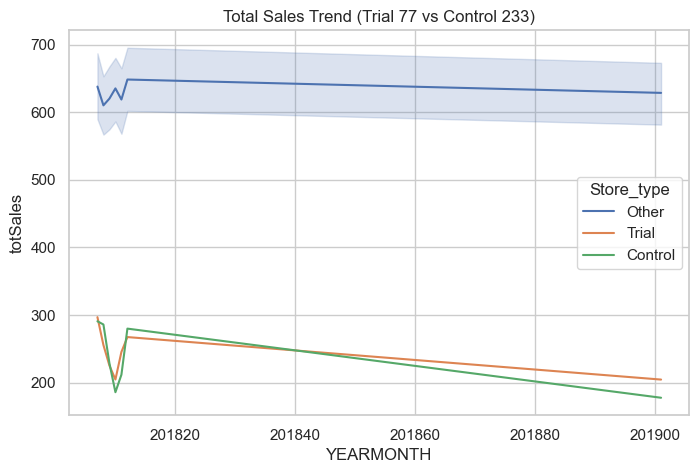

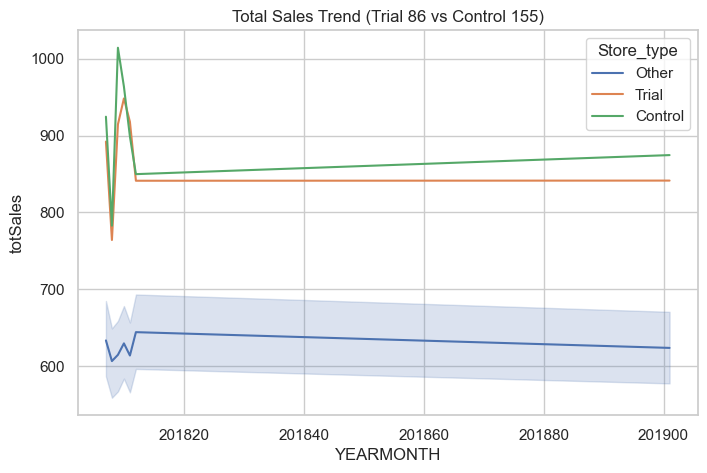

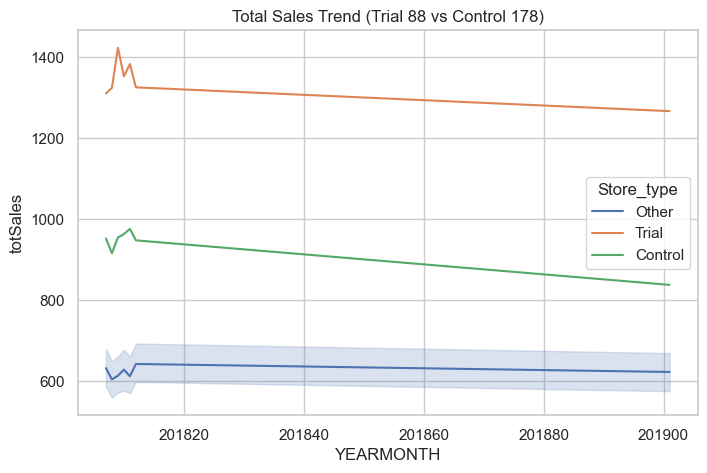

In [34]:
#Visualizations – Pre-Trial Trends

#(For each trial store vs candidate control)

# Visualizing pre-trial trends
for trial, control in results.items():
    temp = preTrialMeasures.copy()
    temp['Store_type'] = temp['STORE_NBR'].apply(
        lambda x: "Trial" if x == trial else ("Control" if x == control else "Other")
    )

    plt.figure(figsize=(8,5))
    sns.lineplot(data=temp, x='YEARMONTH', y='totSales', hue='Store_type')
    plt.title(f"Total Sales Trend (Trial {trial} vs Control {control})")
    plt.show()

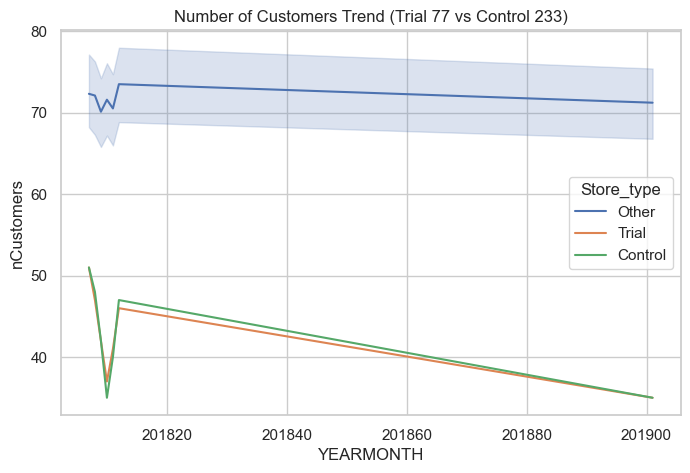

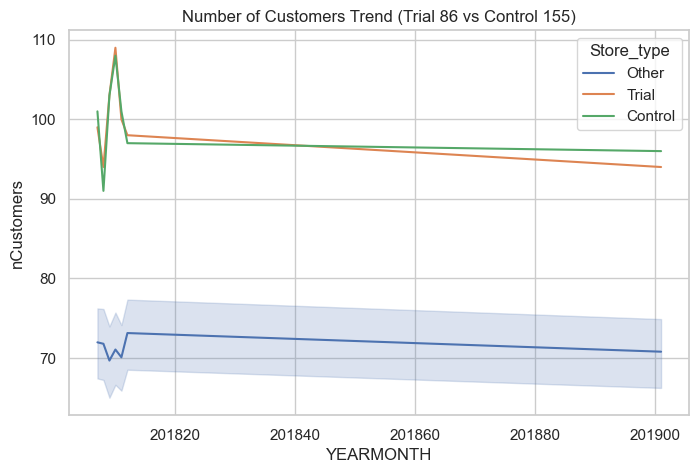

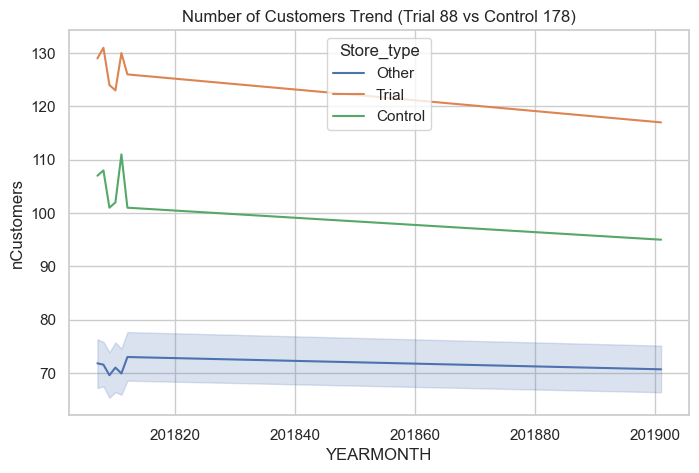

In [36]:
# Visualizing pre-trial customers trend
for trial, control in results.items():
    temp = preTrialMeasures.copy()
    temp['Store_type'] = temp['STORE_NBR'].apply(
        lambda x: "Trial" if x == trial else ("Control" if x == control else "Other")
    )

    plt.figure(figsize=(8,5))
    sns.lineplot(data=temp, x='YEARMONTH', y='nCustomers', hue='Store_type')
    plt.title(f"Number of Customers Trend (Trial {trial} vs Control {control})")
    plt.show()

### Trial Assessment

Trial months: Feb–Apr 2019 (201902–201904)

In [37]:
trialPeriod = measureOverTime[(measureOverTime['YEARMONTH'] >= 201902) &
                              (measureOverTime['YEARMONTH'] <= 201904)]

In [50]:
# #For each trial store: Scaling + Percentage Difference
uplift_results = {}

for trial, control in results.items():

     pre_trial_trial = preTrialMeasures[preTrialMeasures['STORE_NBR'] == trial]['totSales'].sum()
     pre_trial_control = preTrialMeasures[preTrialMeasures['STORE_NBR'] == control]['totSales'].sum()

     scaling_factor = pre_trial_trial / pre_trial_control

     ctrl_scaled = trialPeriod[trialPeriod['STORE_NBR'] == control].copy()
     ctrl_scaled['scaledSales'] = ctrl_scaled['totSales'] * scaling_factor

     trial_sales = trialPeriod[trialPeriod['STORE_NBR'] == trial][['YEARMONTH','totSales']]

     compare = trial_sales.merge(ctrl_scaled[['YEARMONTH','scaledSales']], on='YEARMONTH')
     compare['percentageDiff'] = (compare['totSales'] - compare['scaledSales']) / compare['scaledSales']

     uplift_results[trial] = compare

### Statistical Testing (t-values)

In [51]:
import scipy.stats as stats

t_test_results = {}

for trial in trial_stores:
    df = uplift_results[trial]

    std_dev = df['percentageDiff'].std()
    t_critical = stats.t.ppf(0.95, df.shape[0] - 1)

    df['t_value'] = df['percentageDiff'] / std_dev
    t_test_results[trial] = (df, t_critical)

t_test_results

{77: (   YEARMONTH  totSales  scaledSales  percentageDiff   t_value
  0     201902     235.0   249.762622       -0.059107 -0.171539
  1     201903     278.5   203.802205        0.366521  1.063714
  2     201904     263.5   162.345704        0.623080  1.808296,
  np.float64(2.919985580355516)),
 86: (   YEARMONTH  totSales  scaledSales  percentageDiff   t_value
  0     201902     913.2   864.522060        0.056306  0.360264
  1     201903    1026.8   780.320405        0.315870  2.021027
  2     201904     848.2   819.317024        0.035253  0.225556,
  np.float64(2.919985580355516)),
 88: (   YEARMONTH  totSales  scaledSales  percentageDiff   t_value
  0     201902    1370.2  1561.137395       -0.122307 -1.588018
  1     201903    1477.2  1432.094076        0.031496  0.408948
  2     201904    1439.4  1519.556770       -0.052750 -0.684903,
  np.float64(2.919985580355516))}

### Plot Trial vs Control with Confidence Band

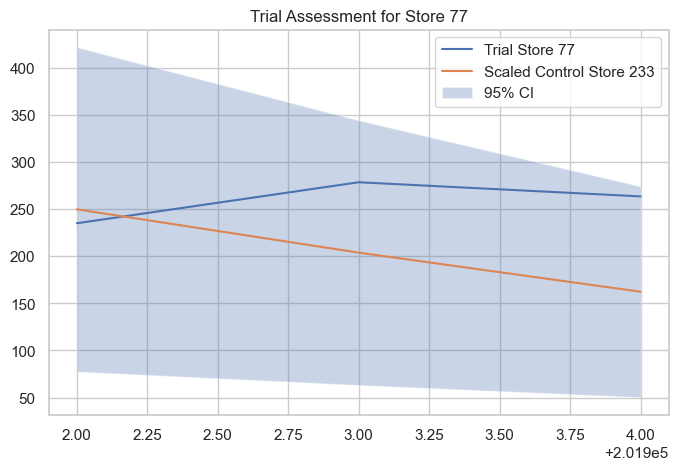

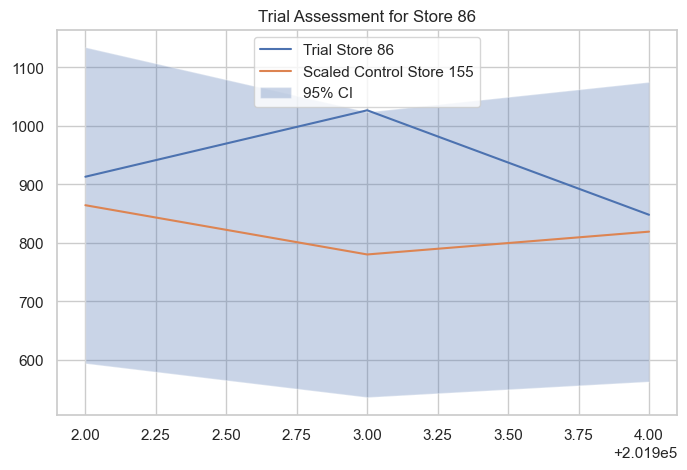

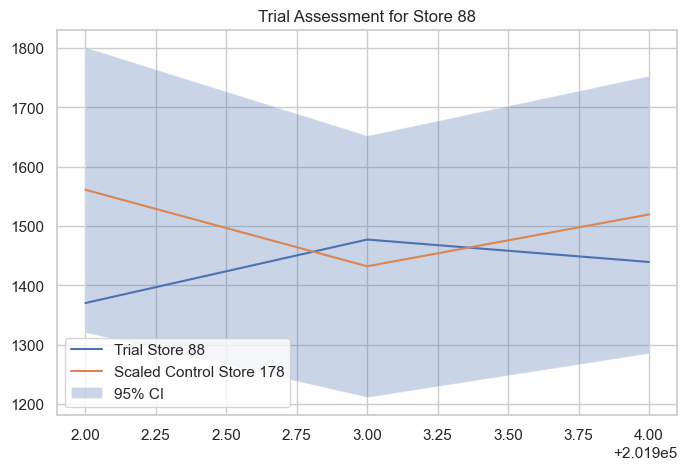

In [41]:
for trial, control in results.items():

    df = uplift_results[trial]
    std_dev = df['percentageDiff'].std()

    plt.figure(figsize=(8,5))
    plt.plot(df['YEARMONTH'], df['totSales'], label=f"Trial Store {trial}")
    plt.plot(df['YEARMONTH'], df['scaledSales'], label=f"Scaled Control Store {control}")

    # Confidence band
    upper = df['scaledSales'] * (1 + std_dev * 2)
    lower = df['scaledSales'] * (1 - std_dev * 2)
    plt.fill_between(df['YEARMONTH'], lower, upper, alpha=0.3, label="95% CI")

    plt.legend()
    plt.title(f"Trial Assessment for Store {trial}")
    plt.show()

### Collate Findings + Recommendations

In [42]:
for trial in trial_stores:
    df, t_critical = t_test_results[trial]
    significant_months = df[abs(df['t_value']) > t_critical]['YEARMONTH'].tolist()

    print(f"\n=== Store {trial} Trial Summary ===")
    print(f"Control Store: {results[trial]}")
    print(f"Significant uplift months: {significant_months}")

    if len(significant_months) >= 2:
        print("Recommendation: Trial SUCCESSFUL – strong uplift detected.")
    else:
        print("Recommendation: Trial NOT significant – weak uplift.")



=== Store 77 Trial Summary ===
Control Store: 233
Significant uplift months: []
Recommendation: Trial NOT significant – weak uplift.

=== Store 86 Trial Summary ===
Control Store: 155
Significant uplift months: []
Recommendation: Trial NOT significant – weak uplift.

=== Store 88 Trial Summary ===
Control Store: 178
Significant uplift months: []
Recommendation: Trial NOT significant – weak uplift.
